# Final Transfer-Aware Model Comparison

This notebook visualizes artifacts produced by
`scripts/final_transfer_experiment.py` (and refreshed by
`scripts/final_transfer_repick.py`).

It **does not retrain** any model — it only reads CSV / JSON outputs
from `artifacts/final_transfer/`.

Sections:

1. Load artifacts + ranked model comparison table
2. Pooled ROC-AUC per model
3. LODO AUC per held-out dataset
4. LODO minimum AUC ranking
5. Domain (fingerprint) AUC comparison (lower is better)
6. VPN AUC vs Domain AUC scatter
7. Calibration curves
8. Confusion-matrix grid (top models)
9. Threshold stability
10. Anti-fingerprint feature importance
11. Final recommendation summary


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
    HAS_SNS = True
except Exception:
    HAS_SNS = False

plt.rcParams['figure.dpi'] = 110

ROOT = Path('..').resolve()
ART  = ROOT / 'artifacts' / 'final_transfer'
REC  = ART  / 'recommended'

print('Artifact root :', ART, '->', 'EXISTS' if ART.exists() else 'MISSING')
print('Recommend dir :', REC, '->', 'EXISTS' if REC.exists() else 'MISSING')

Artifact root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\final_transfer -> EXISTS
Recommend dir : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\final_transfer\recommended -> EXISTS


## 1. Ranked model comparison (by `final_score`)

In [2]:
comp = pd.read_csv(ART / 'model_comparison.csv')
comp = comp.sort_values('final_score', ascending=False).reset_index(drop=True)
print(f'{len(comp)} model rows loaded.')
display_cols = [
    'model_id', 'feature_family', 'family', 'n_features',
    'pooled_auc', 'session_auc', 'lodo_min_auc', 'lodo_mean_auc',
    'domain_auc', 'fpr', 'ece', 'threshold_instability',
    'runtime_compatible', 'final_score',
]
display_cols = [c for c in display_cols if c in comp.columns]
comp[display_cols].round(4).head(20)

31 model rows loaded.


,model_id,feature_family,family,n_features,pooled_auc,session_auc,lodo_min_auc,lodo_mean_auc,domain_auc,fpr,ece,threshold_instability,runtime_compatible,final_score
0,dann__lam0.0,full_canonical,dann,34,0.9875,0.9142,0.5000,0.9875,1.0000,0.0069,0.0208,0.0000,False,0.4886
1,dann__lam0.2,full_canonical,dann,34,0.9744,0.9208,0.4769,0.9744,1.0000,0.0057,0.0236,0.0000,False,0.4582
2,dann__lam0.5,full_canonical,dann,34,0.9665,0.8713,0.4802,0.9665,1.0000,0.0120,0.0245,0.0000,False,0.4522
3,dann__lam0.05,full_canonical,dann,34,0.9837,0.8614,0.4587,0.9837,1.0000,0.0044,0.0192,0.0000,False,0.4458
4,dann__lam1.0,full_canonical,dann,34,0.9264,0.7459,0.5000,0.9264,1.0000,0.0135,0.0414,0.0000,False,0.4442
5,full_canonical__lgbm,full_canonical,lgbm,34,0.9994,1.0000,0.6164,0.6531,1.0000,0.0025,0.0026,0.0346,True,0.4336
6,full_canonical__xgb,full_canonical,xgb,34,0.9990,0.9967,0.6164,0.6531,1.0000,0.0018,0.0046,0.0346,True,0.4331
7,full_canonical__cat,full_canonical,cat,34,0.9980,0.9835,0.6164,0.6531,1.0000,0.0023,0.0055,0.0346,True,0.4329
8,full_canonical__calibrated_ensemble,full_canonical,calibrated_ensemble,34,0.9800,0.9967,0.6164,0.6531,1.0000,0.0039,0.0089,0.0346,True,0.4320
9,full_canonical__bagging,full_canonical,bagging,34,0.9989,0.9967,0.6164,0.6531,1.0000,0.0031,0.0189,0.0346,True,0.4295


## 2. Pooled ROC-AUC per model

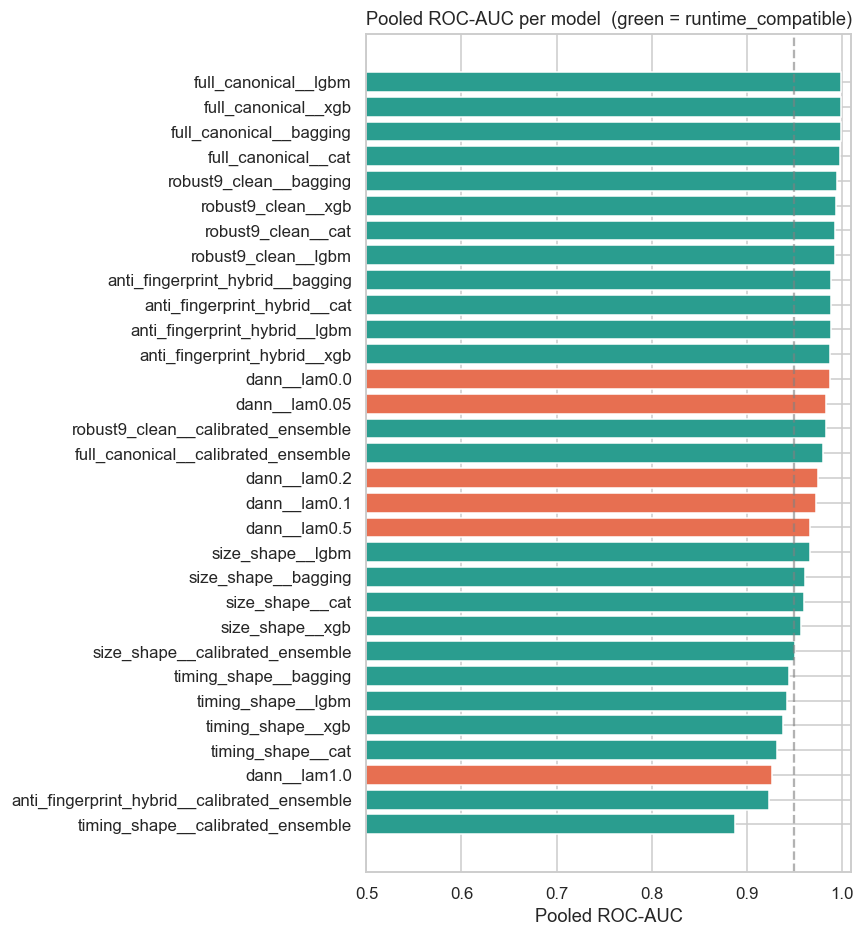

In [3]:
d = comp.sort_values('pooled_auc', ascending=True)
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
colors = ['#2a9d8f' if rc else '#e76f51' for rc in d['runtime_compatible']]
ax.barh(d['model_id'], d['pooled_auc'], color=colors)
ax.set_xlabel('Pooled ROC-AUC')
ax.set_xlim(0.5, 1.01)
ax.set_title('Pooled ROC-AUC per model  (green = runtime_compatible)')
ax.axvline(0.95, ls='--', color='grey', alpha=.6)
plt.tight_layout(); plt.show()

## 3. LODO AUC per held-out dataset

LODO folds: ['lodo_iscx_auc', 'lodo_usbvpn_auc', 'lodo_vnat_auc']


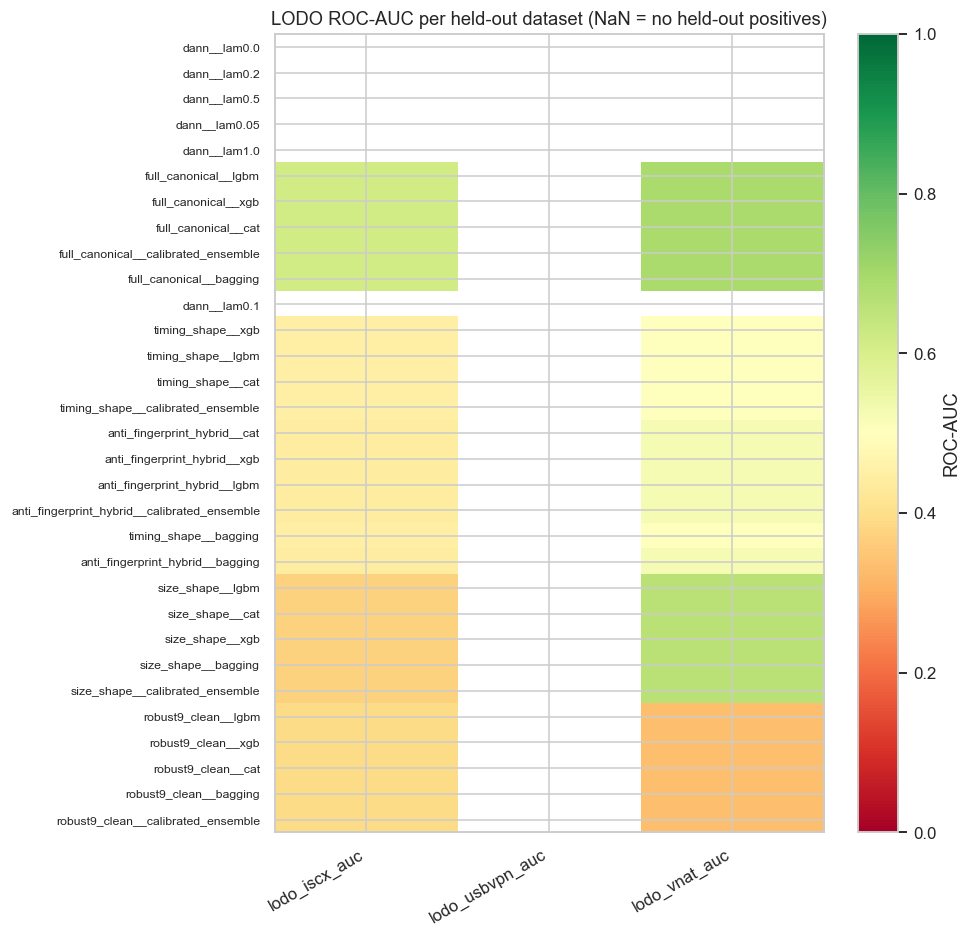

In [4]:
lodo_cols = [c for c in comp.columns if c.startswith('lodo_') and c.endswith('_auc')
              and c not in ('lodo_mean_auc', 'lodo_min_auc')]
print('LODO folds:', lodo_cols)

lodo = comp[['model_id'] + lodo_cols].copy().set_index('model_id')
fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(lodo))))
im = ax.imshow(lodo.values.astype(float), aspect='auto', cmap='RdYlGn', vmin=0.0, vmax=1.0)
ax.set_yticks(range(len(lodo))); ax.set_yticklabels(lodo.index, fontsize=8)
ax.set_xticks(range(len(lodo_cols))); ax.set_xticklabels(lodo_cols, rotation=30, ha='right')
ax.set_title('LODO ROC-AUC per held-out dataset (NaN = no held-out positives)')
plt.colorbar(im, ax=ax, label='ROC-AUC')
plt.tight_layout(); plt.show()

## 4. LODO minimum AUC ranking (transfer hardness floor)

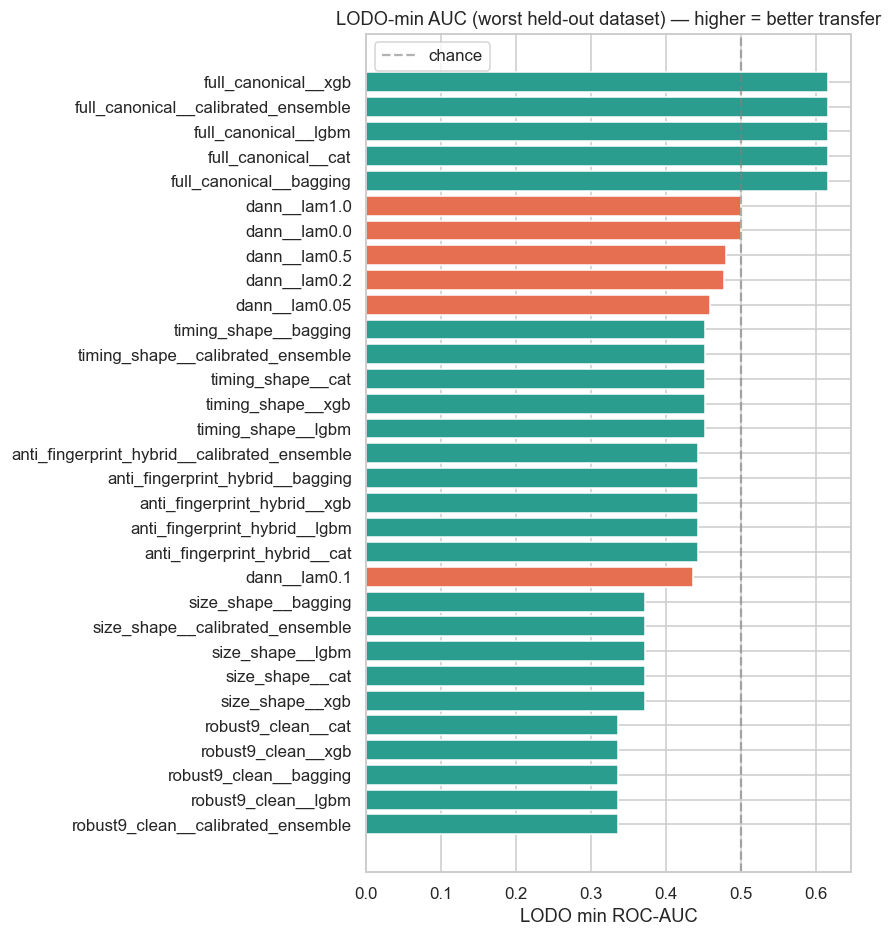

In [5]:
d = comp.dropna(subset=['lodo_min_auc']).sort_values('lodo_min_auc', ascending=True)
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
colors = ['#2a9d8f' if rc else '#e76f51' for rc in d['runtime_compatible']]
ax.barh(d['model_id'], d['lodo_min_auc'], color=colors)
ax.axvline(0.5, color='grey', ls='--', alpha=.6, label='chance')
ax.set_xlabel('LODO min ROC-AUC')
ax.set_title('LODO-min AUC (worst held-out dataset) — higher = better transfer')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Domain (fingerprint) AUC — lower is better

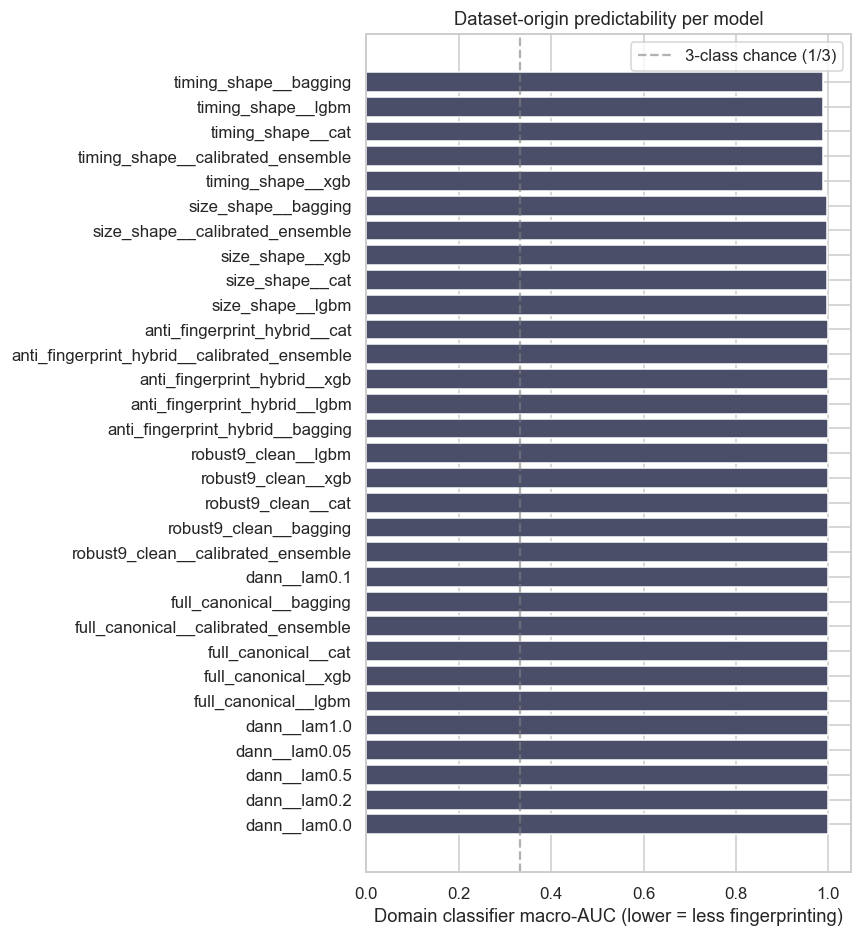

In [6]:
if 'domain_auc' not in comp.columns:
    print('domain_auc not in comparison table.')
else:
    d = comp.dropna(subset=['domain_auc']).sort_values('domain_auc', ascending=False)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
    ax.barh(d['model_id'], d['domain_auc'], color='#4a4e69')
    ax.axvline(1/3, color='grey', ls='--', alpha=.6, label='3-class chance (1/3)')
    ax.set_xlabel('Domain classifier macro-AUC (lower = less fingerprinting)')
    ax.set_title('Dataset-origin predictability per model')
    ax.legend(); plt.tight_layout(); plt.show()

## 6. VPN AUC vs Domain AUC scatter

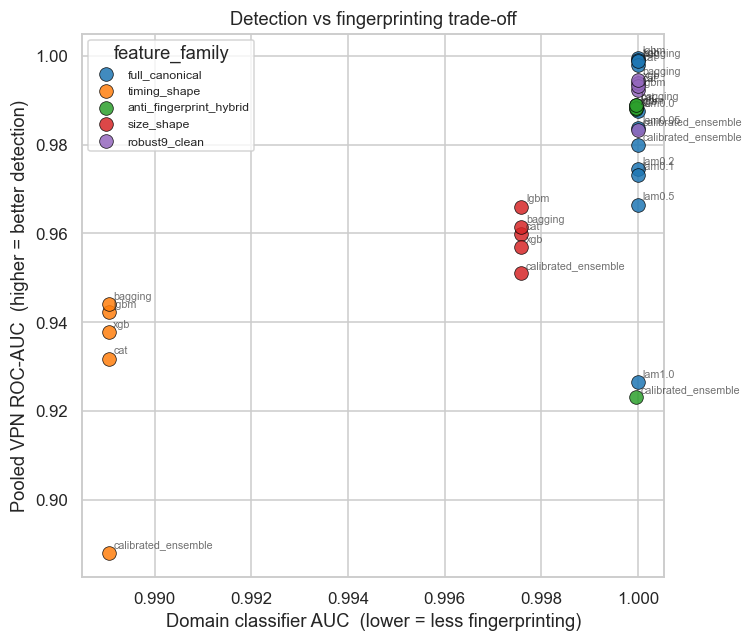

In [7]:
d = comp.dropna(subset=['pooled_auc', 'domain_auc']).copy()
fig, ax = plt.subplots(figsize=(7, 6))
fams = d['feature_family'].unique()
cmap = plt.cm.tab10
for i, ff in enumerate(fams):
    sub = d[d['feature_family'] == ff]
    ax.scatter(sub['domain_auc'], sub['pooled_auc'], s=80, alpha=.85,
               label=ff, color=cmap(i % 10),
               edgecolor='black', linewidth=.5)
for _, r in d.iterrows():
    ax.annotate(r['model_id'].split('__')[-1],
                (r['domain_auc'], r['pooled_auc']),
                fontsize=7, alpha=.65, xytext=(3, 3),
                textcoords='offset points')
ax.set_xlabel('Domain classifier AUC  (lower = less fingerprinting)')
ax.set_ylabel('Pooled VPN ROC-AUC  (higher = better detection)')
ax.set_title('Detection vs fingerprinting trade-off')
ax.legend(fontsize=8, title='feature_family')
plt.tight_layout(); plt.show()

## 7. Calibration curves

Plot calibration for the four recommended slots from their saved
`val_predictions.csv`. We use the validation split (the same split
used to fit calibrators / pick thresholds).

skip best_offline: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']
skip best_transfer: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']
skip best_low_fingerprint: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']
skip recommended_firewall: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']


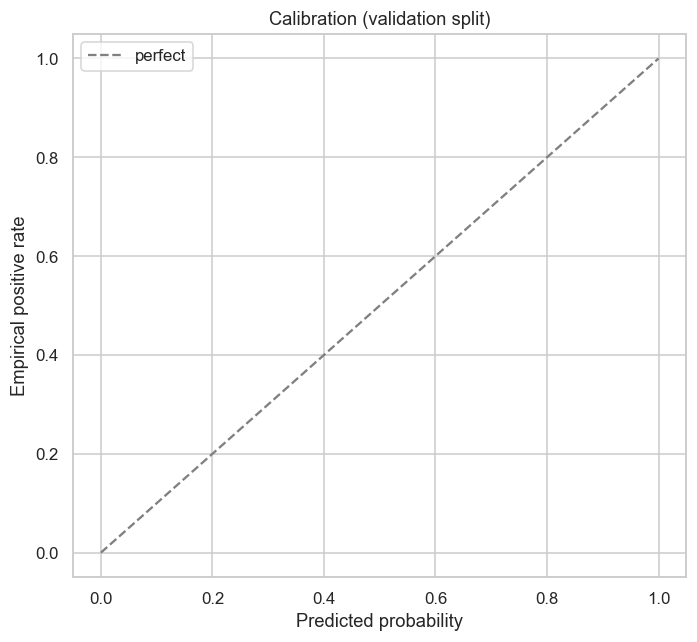

In [8]:
from sklearn.calibration import calibration_curve

slots = ['best_offline', 'best_transfer', 'best_low_fingerprint', 'recommended_firewall']
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect')

for slot in slots:
    pf = REC / slot / 'val_predictions.csv'
    if not pf.exists():
        print(f'skip {slot}: no val_predictions')
        continue
    df = pd.read_csv(pf)
    prob_col = next((c for c in ('prob', 'prob_cal', 'score', 'y_prob', 'p') if c in df.columns), None)
    y_col    = next((c for c in ('y_true', 'label', 'y') if c in df.columns), None)
    if prob_col is None or y_col is None:
        print(f'skip {slot}: cols={list(df.columns)}')
        continue
    frac_pos, mean_pred = calibration_curve(df[y_col], df[prob_col], n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=slot)

ax.set_xlabel('Predicted probability')
ax.set_ylabel('Empirical positive rate')
ax.set_title('Calibration (validation split)')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Confusion-matrix grid

Top models by `final_score` evaluated on their saved
`test_predictions.csv` at the model-specific threshold stored
in `thresholds.json` (slot models) or 0.5 fallback.

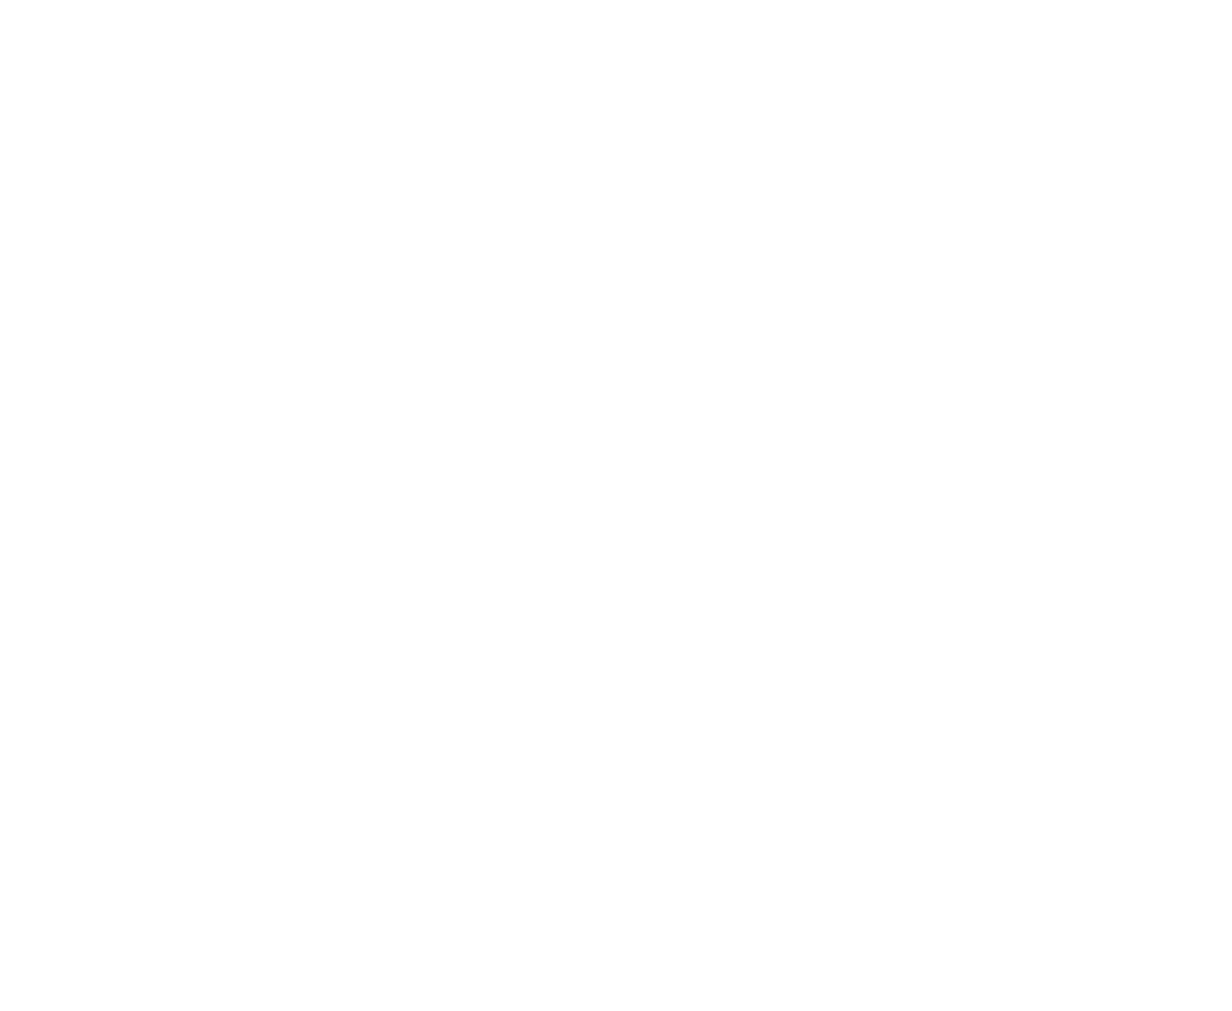

In [9]:
from sklearn.metrics import confusion_matrix

slot_dirs = [(slot, REC / slot) for slot in
             ('best_offline', 'best_transfer', 'best_low_fingerprint', 'recommended_firewall')
             if (REC / slot).exists()]

n = len(slot_dirs)
if n == 0:
    print('No recommended slots found.')
else:
    cols = min(n, 2); rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.5 * rows), squeeze=False)
    for ax, (slot, d) in zip(axes.flatten(), slot_dirs):
        pf = d / 'test_predictions.csv'
        tf = d / 'thresholds.json'
        if not pf.exists():
            ax.set_visible(False); continue
        df = pd.read_csv(pf)
        prob_col = next((c for c in ('prob', 'prob_cal', 'score', 'y_prob', 'p') if c in df.columns), None)
        y_col    = next((c for c in ('y_true', 'label', 'y') if c in df.columns), None)
        if prob_col is None or y_col is None:
            ax.set_visible(False); continue
        thr = 0.5
        if tf.exists():
            try:
                tj = json.loads(tf.read_text(encoding='utf-8'))
                thr = float(tj.get('flow_threshold',
                            tj.get('threshold',
                            tj.get('block_threshold', 0.5))))
            except Exception:
                pass
        pred = (df[prob_col] >= thr).astype(int)
        cm = confusion_matrix(df[y_col], pred, labels=[0, 1])
        im = ax.imshow(cm, cmap='Blues')
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, f'{v}', ha='center', va='center',
                    color='white' if v > cm.max() * 0.6 else 'black',
                    fontsize=11, fontweight='bold')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['nonVPN', 'VPN']); ax.set_yticklabels(['nonVPN', 'VPN'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{slot}\nthr={thr:.3f}')
    for ax in axes.flatten()[len(slot_dirs):]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

## 9. Threshold stability across seeds

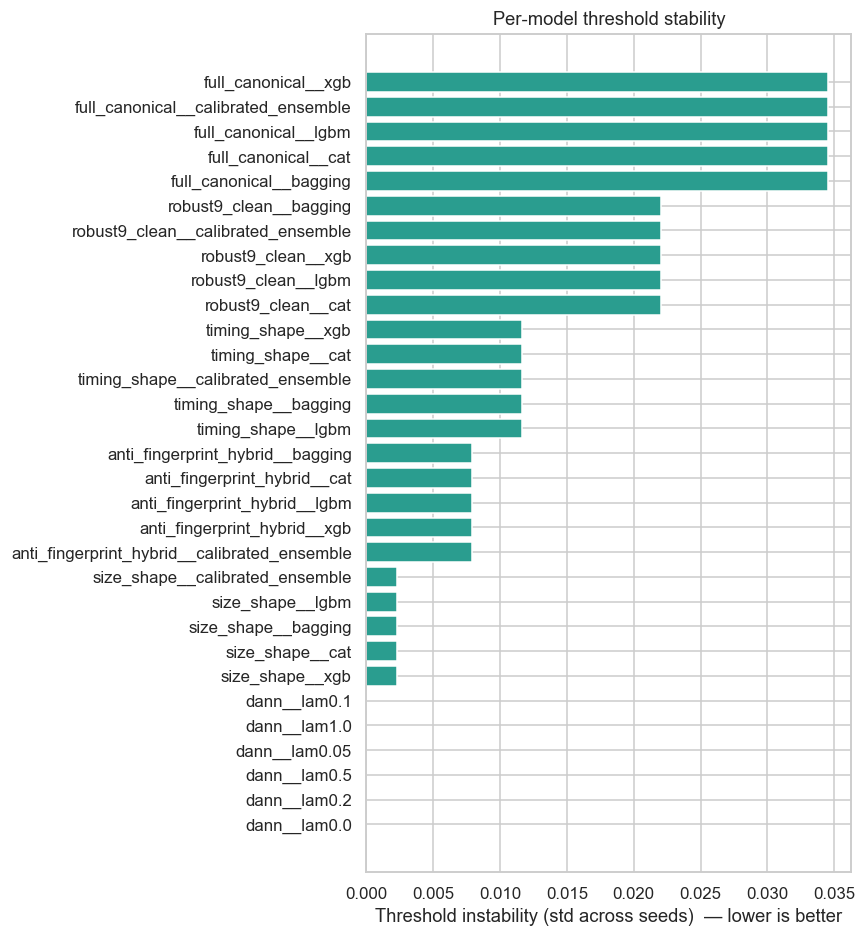

In [10]:
if 'threshold_instability' not in comp.columns:
    print('threshold_instability column missing')
else:
    d = comp.dropna(subset=['threshold_instability']).sort_values('threshold_instability', ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
    colors = ['#2a9d8f' if rc else '#e76f51' for rc in d['runtime_compatible']]
    ax.barh(d['model_id'], d['threshold_instability'], color=colors)
    ax.set_xlabel('Threshold instability (std across seeds)  — lower is better')
    ax.set_title('Per-model threshold stability')
    plt.tight_layout(); plt.show()

## 10. Anti-fingerprint feature score table

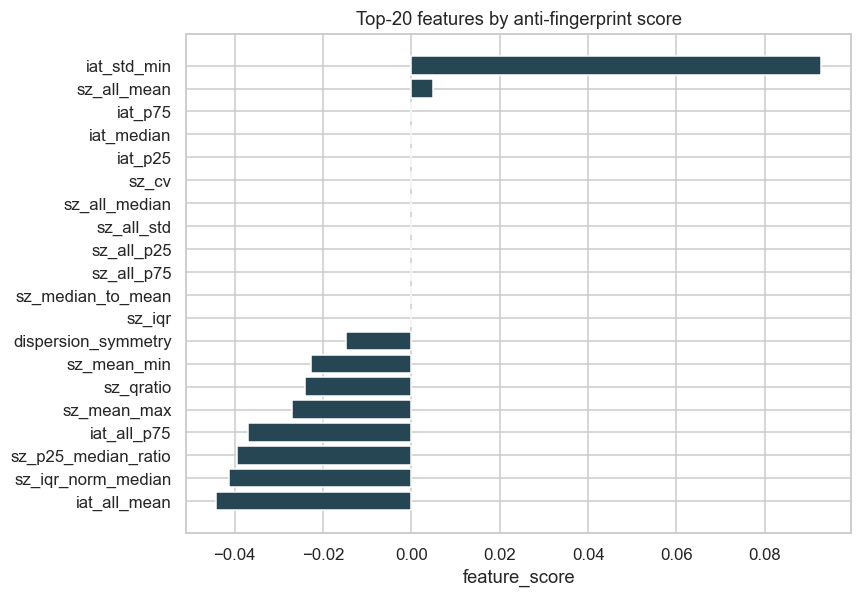

            feature  vpn_importance  domain_importance  instability_penalty  construction_penalty  feature_score
        iat_std_min          0.1118             0.0000               0.0636                   0.0         0.0928
        sz_all_mean          0.0050             0.0000               0.0000                   0.0         0.0050
            iat_p75          0.0000             0.0000               0.0000                   0.0         0.0000
         iat_median          0.0000             0.0000               0.0000                   0.0         0.0000
            iat_p25          0.0000             0.0000               0.0000                   0.0         0.0000
              sz_cv          0.0000             0.0000               0.0000                   0.0         0.0000
      sz_all_median          0.0000             0.0000               0.0000                   0.0         0.0000
         sz_all_std          0.0000             0.0000               0.0000                   0.

In [11]:
afp_path = ART / 'anti_fingerprint_scores.csv'
if not afp_path.exists():
    print('anti_fingerprint_scores.csv missing')
else:
    afp = pd.read_csv(afp_path)
    score_col = next((c for c in ('feature_score', 'score', 'final_score') if c in afp.columns), None)
    if score_col is None:
        print('no score column; have', list(afp.columns))
    else:
        afp = afp.sort_values(score_col, ascending=False).reset_index(drop=True)
        topk = afp.head(20)
        fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(topk))))
        ax.barh(topk['feature'][::-1], topk[score_col][::-1], color='#264653')
        ax.set_xlabel(score_col)
        ax.set_title('Top-20 features by anti-fingerprint score')
        plt.tight_layout(); plt.show()
        print(afp.head(20).round(4).to_string(index=False))

## 11. Final recommendation summary

In [12]:
rec_path = ART / 'recommended_models.json'
if not rec_path.exists():
    print('recommended_models.json missing')
else:
    rec = json.loads(rec_path.read_text(encoding='utf-8'))
    rows = []
    for slot, info in rec.items():
        d = dict(info)
        d.pop('metrics', None)
        d['slot'] = slot
        rows.append(d)
    summary = pd.DataFrame(rows)
    keep = [c for c in [
        'slot', 'model_id', 'feature_family', 'family', 'n_features',
        'pooled_auc', 'lodo_min_auc', 'lodo_mean_auc',
        'domain_auc', 'fpr', 'ece', 'threshold_instability',
        'runtime_compatible', 'final_score',
    ] if c in summary.columns]
    summary = summary[keep].set_index('slot')
    print('=== Recommended models ===')
    print(summary.round(4).to_string())
    fw = rec.get('recommended_firewall', {})
    print('\n>>> FIREWALL PROTOTYPE RECOMMENDATION <<<')
    print(f'  model_id            : {fw.get("model_id")}')
    print(f'  feature_family      : {fw.get("feature_family")}')
    print(f'  n_features          : {fw.get("n_features")}')
    print(f'  pooled_auc          : {fw.get("pooled_auc")}')
    print(f'  lodo_min_auc        : {fw.get("lodo_min_auc")}')
    print(f'  domain_auc          : {fw.get("domain_auc")}')
    print(f'  runtime_compatible  : {fw.get("runtime_compatible")}')
    print(f'  final_score         : {fw.get("final_score")}')

=== Recommended models ===
                                  model_id  feature_family family  n_features  pooled_auc  lodo_min_auc  lodo_mean_auc  domain_auc     fpr     ece  threshold_instability  runtime_compatible  final_score
slot                                                                                                                                                                                                      
best_offline          full_canonical__lgbm  full_canonical   lgbm          34      0.9994        0.6164         0.6531      1.0000  0.0025  0.0026                 0.0346                True       0.4336
best_transfer          full_canonical__xgb  full_canonical    xgb          34      0.9990        0.6164         0.6531      1.0000  0.0018  0.0046                 0.0346                True       0.4331
best_low_fingerprint    timing_shape__lgbm    timing_shape   lgbm           5      0.9423        0.4512         0.4756      0.9891  0.0040  0.0098               